# 10 — Surface-Code Experiments with Loom: Memory and Lattice-Surgery CNOT

## Read before you begin

- Revisit notebook 09: **local checks**, **repeated syndrome extraction**, and **detectors**.
- Read the official Loom references: [memory experiment](https://github.com/entropicalabs/QEC-Tutorials/blob/main/1_memory_exp.ipynb) and [AuxCNOT](https://github.com/entropicalabs/QEC-Tutorials/blob/main/2_auxcnot_op.ipynb).

## Goal

This notebook turns the surface-code ideas from notebook 09 into two runnable Loom experiments:

1. Store one logical qubit through repeated noisy checks, then decode it.
2. Apply a logical CNOT by changing surface-code patches with Loom's `AuxCNOT`.

Loom describes **what the error-correction experiment means**; it then compiles that description to a `stim.Circuit`. Stim samples the circuit, and PyMatching decodes detector events.

## How to use this notebook

Run top to bottom. The default settings are a quick learning run, intended to check construction and illustrate trends. The optional reference-scale setting costs substantially more time and is the appropriate setting for a serious scaling study. A crossover in a small Monte Carlo plot is not, by itself, a threshold estimate.

By the end, you should be able to explain why each Loom operation exists, what physical circuit it produces, and how its measurements become detectors or logical readout.


## Setup and execution settings

`Lattice` supplies possible coordinate sites. A `Block` selects the data and ancilla sites that its code actually uses. `Eka` combines a lattice, blocks, and a time-ordered tuple of operation tuples. Operations inside one tuple are scheduled together; each tuple is one Loom time step.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import stim
import pymatching

from loom.eka import Eka, Lattice
from loom.eka.operations import (
    MeasureBlockSyndromes,
    MeasureLogicalX,
    MeasureLogicalZ,
    ResetAllDataQubits,
)
from loom.interpreter import interpret_eka
from loom.executor import (
    ApplicationMode,
    EkaToStimConverter,
    ErrorType,
    HomogeneousTimeIndependentCEM,
)
from loom.executor.op_signature import (
    STR_MEAS,
    STR_RESET,
    STR_SINGLE_QUBIT_CLIFFORD_GATE,
    STR_TWO_QUBIT_GATE,
)
from loom_rotated_surface_code.code_factory import RotatedSurfaceCode
from loom_rotated_surface_code.operations import AuxCNOT

# Use this dictionary for the cells that run simulations below.
QUICK = {"shots": 2_000, "distances": (3, 5), "error_rates": (0.002, 0.02)}

# This is deliberately not used automatically: it is for longer reproductions.
REFERENCE_SCALE = {"shots": 200_000, "distances": (3, 5, 7),
                   "error_rates": (0.001, 0.0025, 0.005, 0.01, 0.02)}

print("Quick learning run:", QUICK)
print("Optional reference-scale run:", REFERENCE_SCALE)


Quick learning run: {'shots': 2000, 'distances': (3, 5), 'error_rates': (0.002, 0.02)}
Optional reference-scale run: {'shots': 200000, 'distances': (3, 5, 7), 'error_rates': (0.001, 0.0025, 0.005, 0.01, 0.02)}


# Part 1 — Logical memory

## 1. What are we simulating?

A distance-three rotated patch stores one logical qubit while its local stabilizers are measured repeatedly. We prepare either a logical Z-basis state (`|0⟩_L` or `|1⟩_L`) or X-basis state (`|+⟩_L` or `|−⟩_L`), measure checks, idle through more measurement rounds, and finally read the matching logical observable.

Without noise, the final logical parity is fixed by preparation and no detector should fire. With noise, raw check measurements can change. A detector is a parity predicted to be fixed when the circuit is fault-free; it need not compare exactly two raw outcomes. A decoding success is an agreement between the decoder's predicted observable flip and Stim's sampled observable flip. The sampled flip is only a change relative to the tracked reference; it is not automatically an uncorrectable logical error.


## 2. Define and inspect a real Loom patch

For this square lattice, coordinates are `(x, y, layer)`. Layer `0` holds data qubits and layer `1` holds check ancillas. The `4 × 4` lattice gives Loom room for boundary ancillas, but the distance-three block itself has `3² = 9` data qubits, eight independent stabilizers, and one logical qubit: `9 − 8 = 1`.


In [2]:
memory_distance = 3
memory_lattice = Lattice.square_2d((memory_distance + 1, memory_distance + 1))

# The factory chooses a consistent checkerboard, boundaries, logical strings, and schedules.
memory_block = RotatedSurfaceCode.create(
    dx=memory_distance,
    dz=memory_distance,
    lattice=memory_lattice,
    unique_label="memory",
)

print("available lattice sites:", len(memory_lattice.all_qubits()))
print("data qubits:", memory_block.data_qubits)
print("ancilla qubits:", sorted(memory_block.ancilla_qubits))
print("independent stabilizers:", memory_block.reduced_stabarray.nstabs)
print("logical X:", memory_block.logical_x_operators[0])
print("logical Z:", memory_block.logical_z_operators[0])


available lattice sites: 32
data qubits: ((0, 0, 0), (0, 1, 0), (0, 2, 0), (1, 0, 0), (1, 1, 0), (1, 2, 0), (2, 0, 0), (2, 1, 0), (2, 2, 0))
ancilla qubits: [(0, 1, 1), (1, 1, 1), (1, 2, 1), (1, 3, 1), (2, 0, 1), (2, 1, 1), (2, 2, 1), (3, 2, 1)]
independent stabilizers: 8
logical X: X_(0, 0, 0) X_(1, 0, 0) X_(2, 0, 0)
logical Z: Z_(0, 0, 0) Z_(0, 1, 0) Z_(0, 2, 0)


In [3]:
def describe_stabilizer(stabilizer):
    """Print one check's Pauli support and the physical ancilla that measures it."""
    print(f"{stabilizer.pauli}: data {stabilizer.data_qubits}; ancilla {stabilizer.ancilla_qubits}")

x_check = next(check for check in memory_block.stabilizers if check.pauli.startswith("X"))
z_check = next(check for check in memory_block.stabilizers if check.pauli.startswith("Z"))

print("Selected X check")
describe_stabilizer(x_check)
print("Selected Z check")
describe_stabilizer(z_check)


Selected X check
XXXX: data ((1, 1, 0), (1, 2, 0), (0, 1, 0), (0, 2, 0)); ancilla ((1, 2, 1),)
Selected Z check
ZZZZ: data ((1, 0, 0), (0, 0, 0), (1, 1, 0), (0, 1, 0)); ancilla ((1, 1, 1),)


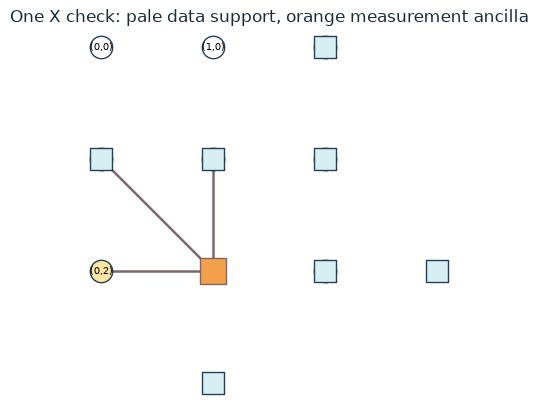

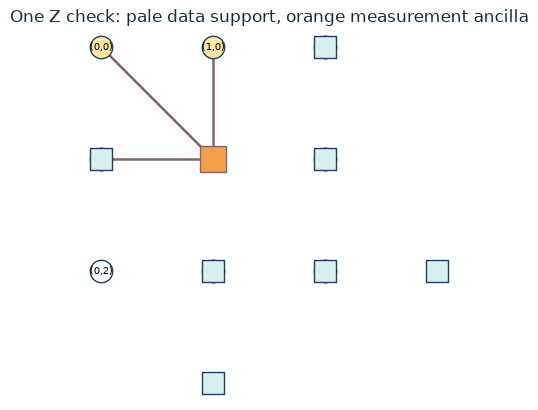

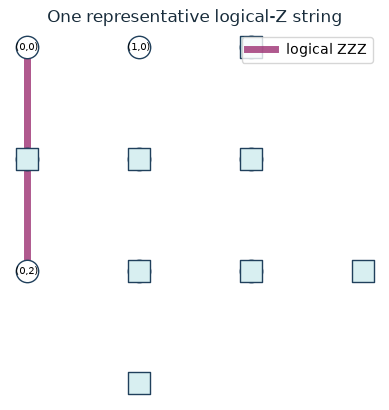

In [4]:
def draw_patch(block, selected_check=None, logical=None, title="Rotated surface-code patch"):
    """Draw data, ancillas, and exactly one optional teaching overlay on a light canvas."""
    fig, ax = plt.subplots(figsize=(5.4, 4.8), facecolor="white")
    data = set(block.data_qubits)
    ancillas = set(block.ancilla_qubits)
    support = set(selected_check.data_qubits) if selected_check else set()
    logical_support = set(logical.data_qubits) if logical else set()
    for x, y, layer in sorted(data | ancillas):
        if layer == 0:
            color = "#ffe7a3" if (x, y, layer) in support else "white"
            edge = "#20405c"
            marker = "o"
        else:
            color, edge, marker = "#d8eff1", "#20405c", "s"
        ax.scatter(x, y, s=260, marker=marker, c=color, edgecolors=edge, zorder=3)
        if layer == 0:
            ax.text(x, y, f"({x},{y})", ha="center", va="center", fontsize=7)
    if selected_check:
        ax.scatter(*selected_check.ancilla_qubits[0][:2], s=350, marker="s",
                   c="#f2a04c", edgecolors="#7f6668", zorder=4)
        for q in support:
            ax.plot([selected_check.ancilla_qubits[0][0], q[0]],
                    [selected_check.ancilla_qubits[0][1], q[1]], color="#7f6668", lw=1.8)
    if logical:
        xs, ys = zip(*[(q[0], q[1]) for q in logical_support])
        ax.plot(xs, ys, color="#9c2f72", lw=5, alpha=.8, zorder=2, label=f"logical {logical.pauli}")
        ax.legend(loc="upper right")
    ax.set_title(title, color="#172b3a")
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")
    plt.show()

draw_patch(memory_block, selected_check=x_check,
           title="One X check: pale data support, orange measurement ancilla")
draw_patch(memory_block, selected_check=z_check,
           title="One Z check: pale data support, orange measurement ancilla")
draw_patch(memory_block, logical=memory_block.logical_z_operators[0],
           title="One representative logical-Z string")


The plots use this notebook's own colors: white circles are data qubits, blue squares are available check ancillas, and the orange square is the selected check's ancilla. The factory's Plotly visualizer uses different default colors (X orange and Z cyan), so these colors should not be carried across tools.

## 3. From one check to one physical circuit

Each selected check points to a generated `SyndromeCircuit`. The circuit has an ancilla reset, a Hadamard, four scheduled `C{P}` interactions, a final Hadamard, and a measurement. On conversion, Loom maps the X-check template to controlled-X interactions and the Z-check template to controlled-Z interactions. The leading and trailing Hadamards make the ancilla's X-basis measurement work in both cases.


In [5]:
def show_check_template(block, stabilizer):
    """Show the factory template associated with one stabilizer, before it is placed on real qubits."""
    circuit_id = block.stabilizer_to_circuit[stabilizer.uuid]
    template = next(item for item in block.syndrome_circuits if item.uuid == circuit_id)
    print(f"{stabilizer.pauli} uses template {template.name!r}:")
    print(template.circuit)

show_check_template(memory_block, x_check)
show_check_template(memory_block, z_check)


XXXX uses template 'xxxx':
xxxx (8 ticks)
0: reset_0
1: h
2: cx
3: cx
4: cx
5: cx
6: h
7: measurement
ZZZZ uses template 'zzzz':
zzzz (8 ticks)
0: reset_0
1: h
2: cz
3: cz
4: cz
5: cz
6: h
7: measurement


### Prediction

If all data qubits start in `|0⟩`, which check type has a predictable `+1` outcome before any fault: X checks or Z checks? Explain from the Pauli support, then run the next cells.

## 4. Initialization, rounds, and readout

Resetting all data qubits to `0` or `1` fixes every even-weight Z check and fixes the logical-Z parity. X-check outcomes can be random because those states are not X eigenstates. The reverse holds for `+` and `−`: X checks and logical-X are fixed, while Z checks may be random. Measuring all checks projects the state into a stabilizer sector; Loom tracks its random initial signs as a Pauli-frame convention, so later *changes* remain meaningful without physically applying corrections.


In [6]:
def make_memory_experiment(distance, state, rounds=None):
    """Build a complete Loom memory recipe for one preparation and one final basis."""
    rounds = distance if rounds is None else rounds
    lattice = Lattice.square_2d((distance + 1, distance + 1))
    block = RotatedSurfaceCode.create(distance, distance, lattice, unique_label="memory")
    readout = MeasureLogicalZ("memory") if state in ("0", "1") else MeasureLogicalX("memory")
    operations = (
        # Reset prepares product states; the first check round projects into a code sector.
        (ResetAllDataQubits("memory", state=state),),
        (MeasureBlockSyndromes("memory", n_cycles=rounds),),
        # The matching-basis logical measurement turns a data-qubit parity into an observable.
        (readout,),
    )
    return interpret_eka(Eka(lattice=lattice, blocks=(block,), operations=operations))

initialization = make_memory_experiment(3, "0", rounds=1)
initialization_circuit, initialization_qmap, initialization_cmap = EkaToStimConverter().convert(
    initialization, with_ticks=True
)
print("Stim qubits:", initialization_circuit.num_qubits)
print("raw measurements:", initialization_circuit.num_measurements)
print("detectors:", initialization_circuit.num_detectors)
print("logical observables:", initialization_circuit.num_observables)


Stim qubits: 17
raw measurements: 17
detectors: 8
logical observables: 1


In [7]:
def print_measurement_trace(step, limit=3):
    """Relate Loom's named measurements to syndromes, then to selected detectors."""
    measured_syndromes = [syn for syn in step.syndromes if syn.measurements]
    print("First raw syndrome records:")
    for syndrome in measured_syndromes[:limit]:
        print(" ", syndrome.measurements, "at", syndrome.labels)
    print("Selected detector definitions:")
    for detector in step.detectors[:limit]:
        records = [syndrome.measurements for syndrome in detector.syndromes]
        print(" ", records, "→ detector at", detector.labels)
    print("Logical readout parity:", step.logical_observables[0].measurements)

print_measurement_trace(initialization)
print("\nFirst 34 lines of the compiled circuit:")
print("\n".join(str(initialization_circuit).splitlines()[:34]))


First raw syndrome records:
  (('c_(1, 1, 1)', 0),) at {'space_coordinates': (1, 1, 1), 'time_coordinate': (9,)}
  (('c_(2, 2, 1)', 0),) at {'space_coordinates': (2, 2, 1), 'time_coordinate': (9,)}
  (('c_(1, 2, 1)', 0),) at {'space_coordinates': (1, 2, 1), 'time_coordinate': (9,)}
Selected detector definitions:
  [(), (('c_(1, 1, 1)', 0),)] → detector at {'space_coordinates': (1, 1, 1), 'time_coordinate': (9,)}
  [(), (('c_(2, 2, 1)', 0),)] → detector at {'space_coordinates': (2, 2, 1), 'time_coordinate': (9,)}
  [(), (('c_(2, 0, 1)', 0),)] → detector at {'space_coordinates': (2, 0, 1), 'time_coordinate': (9,)}
Logical readout parity: (('c_(0, 0, 0)', 0), ('c_(0, 1, 0)', 0), ('c_(0, 2, 0)', 0))

First 34 lines of the compiled circuit:
QUBIT_COORDS(0.5, 0.5) 0
QUBIT_COORDS(0.5, 1.5) 1
QUBIT_COORDS(0, 1) 2
QUBIT_COORDS(0.5, 2.5) 3
QUBIT_COORDS(1.5, 0.5) 4
QUBIT_COORDS(1.5, 1.5) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(1.5, 2.5) 7
QUBIT_COORDS(1, 2) 8
QUBIT_COORDS(1, 3) 9
QUBIT_COORDS(2.5, 0.

The initial detector can combine an implicit initialization reference with the first raw check result; middle detectors normally compare syndrome history; final detectors combine the last check with final data measurements. This is why “a detector is always two consecutive checks” is too narrow.

## 5. Noiseless validation and one concrete noisy shot

`EkaToStimConverter.convert` returns the Stim circuit, a Loom-to-Stim qubit mapping, and a Loom-to-Stim measurement-record mapping. The detector sampler returns a Boolean array of shape `(shots, detectors)` and, separately, `(shots, observables)`. The decoder sees only the detector array.


In [8]:
def decode_circuit(circuit, shots):
    """Sample a circuit and compare matching predictions with Stim's observable flips."""
    dem = circuit.detector_error_model(decompose_errors=True)
    decoder = pymatching.Matching.from_detector_error_model(dem)
    detector_events, sampled_flips = circuit.compile_detector_sampler().sample(
        shots=shots, separate_observables=True
    )
    predicted_flips = decoder.decode_batch(detector_events)
    failures = np.any(predicted_flips != sampled_flips, axis=1)
    return detector_events, predicted_flips, sampled_flips, failures

for prepared_state in ("0", "1", "+", "-"):
    step = make_memory_experiment(3, prepared_state)
    circuit, _, _ = EkaToStimConverter().convert(step)
    events, predicted, sampled, failures = decode_circuit(circuit, shots=100)
    print(f"|{prepared_state}⟩_L: detectors={circuit.num_detectors}, "
          f"fired events={events.sum()}, decoder failures={failures.sum()}")


|0⟩_L: detectors=24, fired events=0, decoder failures=0


|1⟩_L: detectors=24, fired events=0, decoder failures=0
|+⟩_L: detectors=24, fired events=0, decoder failures=0
|-⟩_L: detectors=24, fired events=0, decoder failures=0


In [9]:
def loom_depolarizing_noise(step, probability):
    """Attach Loom's reference-style independent one-qubit depolarization after selected gates."""
    # DEPOLARIZING1 applies a random one-qubit Pauli channel to every target of these gates.
    # This includes each target of a two-qubit gate and also resets/measurements.
    return HomogeneousTimeIndependentCEM(
        circuit=step.final_circuit,
        error_type=ErrorType.DEPOLARIZING1,
        application_mode=ApplicationMode.AFTER_GATE,
        error_probability=float(probability),
        target_gates=list(STR_SINGLE_QUBIT_CLIFFORD_GATE | STR_TWO_QUBIT_GATE | STR_RESET | STR_MEAS),
    )

noisy_step = make_memory_experiment(3, "0")
noise_model = loom_depolarizing_noise(noisy_step, probability=0.01)
noisy_circuit, _, _ = EkaToStimConverter().convert(noisy_step, error_models=[noise_model])
events, predicted, sampled, failures = decode_circuit(noisy_circuit, shots=QUICK["shots"])
shot_index = int(np.flatnonzero(events.any(axis=1))[0])

print("first shot containing an event:", shot_index)
print("detector events:", np.flatnonzero(events[shot_index]).tolist())
print("decoder prediction:", predicted[shot_index].astype(int).tolist())
print("sampled observable flip:", sampled[shot_index].astype(int).tolist())
print("success:", not failures[shot_index])


first shot containing an event: 0
detector events: [8]
decoder prediction: [0]
sampled observable flip: [0]
success: True


Agreement in the final line means that the correction implied by the matching graph restores the tracked logical parity. Disagreement is a residual logical error. The physical fault history is not reconstructed uniquely; many histories can cause the same detector pattern.

## 6. Memory comparison: state, rate, and distance

The reference notebook sweeps four preparations, three distances, and many more shots. The quick plot below uses two representative preparations and two distances. Its rates are illustrative. The noise model is explicitly broader than Stim's `after_clifford_depolarization`: it adds independent `DEPOLARIZE1` after selected one- and two-qubit gates, resets, and measurements.


In [10]:
def memory_logical_error_rate(distance, state, physical_error_rate, shots):
    """Compile one noisy Loom memory experiment and return the post-decoding failure rate."""
    step = make_memory_experiment(distance, state)
    circuit, _, _ = EkaToStimConverter().convert(
        step, error_models=[loom_depolarizing_noise(step, physical_error_rate)]
    )
    _, _, _, failures = decode_circuit(circuit, shots)
    return failures.mean()

quick_results = {}
for state in ("0", "+"):
    quick_results[state] = {}
    for distance in QUICK["distances"]:
        quick_results[state][distance] = []
        for rate in QUICK["error_rates"]:
            value = memory_logical_error_rate(distance, state, rate, QUICK["shots"])
            quick_results[state][distance].append(value)
            print(f"state={state:>2}, d={distance}, p={rate:.3g}: logical failure={value:.4f}")


state= 0, d=3, p=0.002: logical failure=0.0025
state= 0, d=3, p=0.02: logical failure=0.1540


state= 0, d=5, p=0.002: logical failure=0.0010


state= 0, d=5, p=0.02: logical failure=0.3260

state= +, d=3, p=0.002: logical failure=0.0035


state= +, d=3, p=0.02: logical failure=0.1775
state= +, d=5, p=0.002: logical failure=0.0020


state= +, d=5, p=0.02: logical failure=0.3290


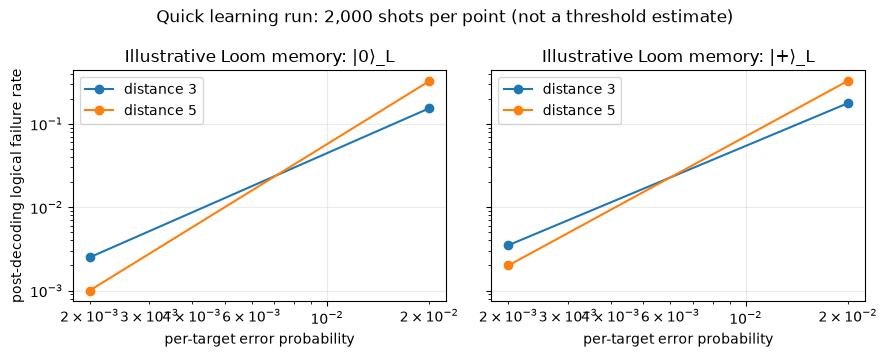

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), facecolor="white", sharey=True)
for axis, state in zip(axes, ("0", "+")):
    for distance, values in quick_results[state].items():
        axis.plot(QUICK["error_rates"], values, "o-", label=f"distance {distance}")
    axis.set(xscale="log", yscale="log", xlabel="per-target error probability",
             title=f"Illustrative Loom memory: |{state}⟩_L", facecolor="white")
    axis.grid(alpha=.25); axis.legend()
axes[0].set_ylabel("post-decoding logical failure rate")
fig.suptitle(f"Quick learning run: {QUICK['shots']:,} shots per point (not a threshold estimate)")
fig.tight_layout()
plt.show()


### Part 1 check-in

1. Why do `|0⟩_L` and `|+⟩_L` use different final logical measurements?
2. Which objects contain the physical patch, the experiment recipe, the interpreted measurements, and the Stim circuit?
3. Why can a detector be deterministic even when an individual raw syndrome is random?
4. What makes a sampled observable flip a decoder failure?

# Part 2 — Lattice surgery and `AuxCNOT`

## 7. What logical operation are we simulating?

We now store two logical qubits: a control patch and a target patch. A CNOT must copy an X eigenvalue from control to target and copy a Z eigenvalue from target to control. In the Heisenberg picture,

\[
X_C \mapsto X_CX_T,\qquad Z_T \mapsto Z_CZ_T,\qquad Z_C \mapsto Z_C,\qquad X_T \mapsto X_T.
\]

The reference's teaching construction prepares an auxiliary `|+⟩_L` patch, measures `Z_C Z_A`, splits, measures `X_A X_T`, and measures the auxiliary in Z. The joint-parity outcomes prescribe Pauli-frame corrections. It establishes the transformations above analytically. Loom's installed `AuxCNOT` is equivalent at the logical level but uses a different physical sequence: **grow control → split it into control and auxiliary → merge auxiliary with target to measure XX → conditionally update logical Z → shrink target**. We verify that actual installed sequence below.


## 8. Patch geometry through the `AuxCNOT` stages

The target is offset by `d + 1` in both directions. This leaves a row and column that let Loom preserve the checkerboard geometry while it grows and merges patches. The auxiliary is not reset from scratch: splitting the expanded control patch creates it while preserving the logical correlations that the operation needs.


In [12]:
cnot_distance = 3
cnot_lattice = Lattice.square_2d((2 * cnot_distance + 2, 2 * cnot_distance + 2))
control_block = RotatedSurfaceCode.create(
    cnot_distance, cnot_distance, cnot_lattice, unique_label="control"
)
# shift preserves the block structure while placing a second copy at a legal surgery location.
target_block = control_block.shift((cnot_distance + 1, cnot_distance + 1)).rename("target")

def make_cnot_experiment(control_state, target_state, basis):
    """Build one two-patch experiment whose final basis tests the logical CNOT action."""
    readout = MeasureLogicalZ if basis == "Z" else MeasureLogicalX
    operations = (
        # Independent product-state preparation before the surgery operation.
        (ResetAllDataQubits("control", state=control_state),
         ResetAllDataQubits("target", state=target_state)),
        # This projects each patch and provides an initial syndrome history.
        (MeasureBlockSyndromes("control", n_cycles=cnot_distance),
         MeasureBlockSyndromes("target", n_cycles=cnot_distance)),
        # AuxCNOT expands into the installed grow/split/merge/conditional-Z/shrink sequence.
        (AuxCNOT(("control", "target")),),
        (readout("control"), readout("target")),
    )
    return interpret_eka(Eka(cnot_lattice, (control_block, target_block), operations), debug_mode=False)

cnot_geometry = make_cnot_experiment("+", "0", "Z")

# Interpretation inserts many syndrome-extraction timestamps. Identify the five geometry
# changes from their actual block labels and sizes instead of assuming fixed timestamps.
cnot_stage_times = {}
for timestamp, block_ids in cnot_geometry.block_history.blocks_over_time():
    blocks = [cnot_geometry.block_registry[block_id] for block_id in block_ids]
    by_name = {block.unique_label: block for block in blocks}
    if "initial" not in cnot_stage_times:
        cnot_stage_times["initial"] = timestamp
    if by_name.get("control") and by_name["control"].size == (7, 3):
        cnot_stage_times.setdefault("grown", timestamp)
    if "control_aux" in by_name:
        cnot_stage_times.setdefault("split", timestamp)
    if by_name.get("target") and by_name["target"].size == (3, 7):
        cnot_stage_times.setdefault("merged", timestamp)
    if (timestamp > cnot_stage_times.get("merged", float("inf")) and
            by_name.get("control") and by_name.get("target") and
            by_name["control"].size == by_name["target"].size == (3, 3)):
        cnot_stage_times.setdefault("restored", timestamp)

for stage in ("initial", "grown", "split", "merged", "restored"):
    timestamp = cnot_stage_times[stage]
    block_ids = cnot_geometry.block_history.blocks_at(timestamp)
    blocks = [cnot_geometry.block_registry[block_id] for block_id in block_ids]
    summary = [(block.unique_label, block.size, block.upper_left_qubit) for block in blocks]
    print(f"{stage:>8} at t={timestamp}: {summary}")


 initial at t=0: [('control', (3, 3), (0, 0, 0)), ('target', (3, 3), (4, 4, 0))]
   grown at t=26: [('control', (7, 3), (0, 0, 0)), ('target', (3, 3), (4, 4, 0))]
   split at t=52: [('control_aux', (3, 3), (4, 0, 0)), ('control', (3, 3), (0, 0, 0)), ('target', (3, 3), (4, 4, 0))]
  merged at t=61: [('control', (3, 3), (0, 0, 0)), ('target', (3, 7), (4, 0, 0))]
restored at t=86: [('control', (3, 3), (0, 0, 0)), ('target', (3, 3), (4, 4, 0))]


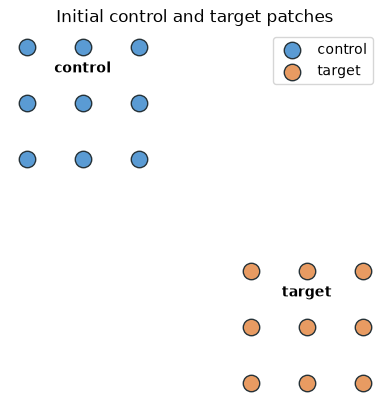

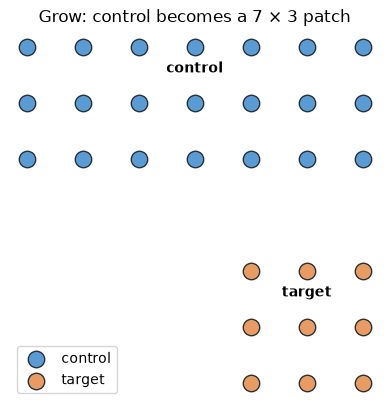

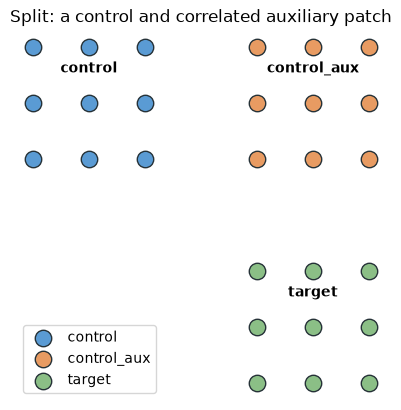

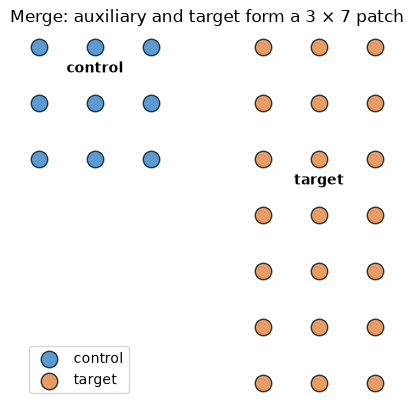

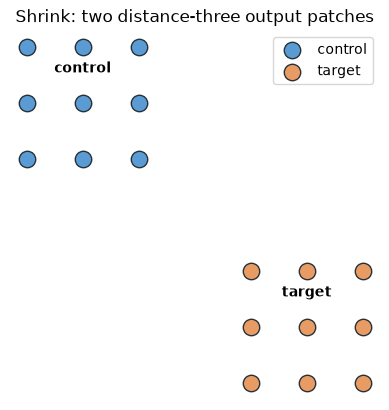

In [13]:
def draw_stage(step, timestamp, title):
    """Plot only the data qubits and check supports active at one surgery stage."""
    block_ids = step.block_history.blocks_at(timestamp)
    blocks = [step.block_registry[block_id] for block_id in block_ids]
    fig, ax = plt.subplots(figsize=(5.4, 4.8), facecolor="white")
    colors = ("#5a9bd4", "#e89b62", "#8bbf86")
    for block, color in zip(sorted(blocks, key=lambda item: item.upper_left_qubit), colors):
        xs = [q[0] for q in block.data_qubits]; ys = [q[1] for q in block.data_qubits]
        ax.scatter(xs, ys, s=140, c=color, edgecolors="#263238", label=block.unique_label)
        ax.text(np.mean(xs), np.mean(ys) - .55, block.unique_label, ha="center", weight="bold")
    ax.set(title=title, aspect="equal", facecolor="white"); ax.invert_yaxis(); ax.axis("off"); ax.legend()
    plt.show()

for stage, title in [("initial", "Initial control and target patches"),
                     ("grown", "Grow: control becomes a 7 × 3 patch"),
                     ("split", "Split: a control and correlated auxiliary patch"),
                     ("merged", "Merge: auxiliary and target form a 3 × 7 patch"),
                     ("restored", "Shrink: two distance-three output patches")]:
    draw_stage(cnot_geometry, cnot_stage_times[stage], title)


In the merge stage, joining X-type boundaries measures the joint `X_A X_T` parity. The installed operation uses that measurement as the condition for a logical-Z Pauli-frame update. No conditional physical gate needs to appear in the sampled circuit: the condition modifies how Loom defines the final logical measurement parity. This is the practical meaning of a Pauli frame here.

## 9. The resulting circuit and numerical CNOT tests

We keep the circuit excerpt small. Its `TICK`s separate scheduled interaction layers; its measurements are the raw records from which Loom attaches detectors and final logical observables. The Z-basis tests check the classical truth-table cases. The `|+⟩_C|0⟩_T` test is complementary: CNOT should create a Bell state, so separate X and Z measurements are random but correlated. Those tests support the implementation; the Pauli transformations above establish the full logical action.


In [14]:
cnot_circuit, cnot_qmap, cnot_cmap = EkaToStimConverter().convert(cnot_geometry, with_ticks=True)
print("CNOT circuit: qubits=", cnot_circuit.num_qubits,
      "measurements=", cnot_circuit.num_measurements,
      "detectors=", cnot_circuit.num_detectors,
      "observables=", cnot_circuit.num_observables)
print("\nSelected beginning of the compiled circuit:")
print("\n".join(str(cnot_circuit).splitlines()[:36]))


CNOT circuit: qubits= 65 measurements= 273 detectors= 232 observables= 2

Selected beginning of the compiled circuit:
QUBIT_COORDS(0.5, 0.5) 0
QUBIT_COORDS(0.5, 1.5) 1
QUBIT_COORDS(0, 1) 2
QUBIT_COORDS(0.5, 2.5) 3
QUBIT_COORDS(1.5, 0.5) 4
QUBIT_COORDS(1.5, 1.5) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(1.5, 2.5) 7
QUBIT_COORDS(1, 2) 8
QUBIT_COORDS(1, 3) 9
QUBIT_COORDS(2.5, 0.5) 10
QUBIT_COORDS(2, 0) 11
QUBIT_COORDS(2.5, 1.5) 12
QUBIT_COORDS(2, 1) 13
QUBIT_COORDS(2.5, 2.5) 14
QUBIT_COORDS(2, 2) 15
QUBIT_COORDS(3.5, 0.5) 16
QUBIT_COORDS(3.5, 1.5) 17
QUBIT_COORDS(3, 1) 18
QUBIT_COORDS(3.5, 2.5) 19
QUBIT_COORDS(3, 2) 20
QUBIT_COORDS(3, 3) 21
QUBIT_COORDS(4.5, 0.5) 22
QUBIT_COORDS(4, 0) 23
QUBIT_COORDS(4.5, 1.5) 24
QUBIT_COORDS(4, 1) 25
QUBIT_COORDS(4.5, 2.5) 26
QUBIT_COORDS(4, 2) 27
QUBIT_COORDS(4.5, 3.5) 28
QUBIT_COORDS(4, 3) 29
QUBIT_COORDS(4.5, 4.5) 30
QUBIT_COORDS(4.5, 5.5) 31
QUBIT_COORDS(4, 5) 32
QUBIT_COORDS(4.5, 6.5) 33
QUBIT_COORDS(5.5, 0.5) 34
QUBIT_COORDS(5.5, 1.5) 35


In [15]:
def logical_outcome_counts(step, shots):
    """Convert raw Stim records back through Loom's named logical-measurement definitions."""
    converter = EkaToStimConverter()
    circuit, _, classical_map = converter.convert(step)
    raw_samples = circuit.compile_sampler().sample(shots=shots)
    named_records = converter.parse_target_run_outcome((raw_samples, classical_map))
    logical_bits = []
    for observable in step.logical_observables:
        # A logical outcome is the XOR of every physical record Loom associates with it.
        records = [named_records[f"{label}_{round_number}"]
                   for label, round_number in observable.measurements]
        logical_bits.append(np.bitwise_xor.reduce(records, axis=0).astype(int))
    bit_strings = ["".join(str(bit) for bit in column) for column in np.array(logical_bits).T]
    return {outcome: bit_strings.count(outcome) for outcome in sorted(set(bit_strings))}

for control_state, target_state in (("0", "0"), ("1", "0"), ("1", "1")):
    step = make_cnot_experiment(control_state, target_state, "Z")
    print(f"|{control_state}{target_state}⟩_L in Z →", logical_outcome_counts(step, shots=300))

for basis in ("Z", "X"):
    bell_step = make_cnot_experiment("+", "0", basis)
    print(f"|+0⟩_L measured in {basis} →", logical_outcome_counts(bell_step, shots=500))


|00⟩_L in Z → {'00': 300}


|10⟩_L in Z → {'11': 300}
|11⟩_L in Z → {'10': 300}


|+0⟩_L measured in Z → {'00': 252, '11': 248}


|+0⟩_L measured in X → {'00': 265, '11': 235}


### Part 2 check-in

1. What information does the auxiliary patch carry after splitting the grown control?
2. Which joint parity does this installed `AuxCNOT` measure at its merge stage?
3. Why can a conditional logical correction be represented by changing a final readout parity?
4. How do the `|+0⟩_L` X- and Z-basis tests probe more than a computational-basis truth table?

## Exercises

1. Change the memory experiment from `|0⟩_L` to `|−⟩_L`. Which final logical measurement must change, and why?
2. Print a different detector in `print_measurement_trace`. Which raw records and syndrome rounds enter its parity?
3. Run `memory_logical_error_rate` with `REFERENCE_SCALE`, then add confidence intervals before interpreting a crossover.
4. Change the CNOT preparation to `|0+⟩_L`. Which Pauli transformation predicts the effect, and which basis should you measure?

**Bridge.** Notebook 11 moves from a stabilizer-simulator description to hardware-aware Guppy programs. This notebook's lattice and operation choices describe a physical experiment; the compiled Stim circuit remains a fast model, not hardware calibration data.
